# Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load excel file
df = pd.read_excel('Tourism_data.xlsx')

In [3]:
df.head()

,Year,Guest nights ('000),Tax revenue ($m)
0,1980,20745,2752
1,1981,20293,2814
2,1982,21972,3824
3,1983,23785,3739
4,1984,21649,2366


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Year                 45 non-null     int64
 1   Guest nights ('000)  45 non-null     int64
 2   Tax revenue ($m)     45 non-null     int64
dtypes: int64(3)
memory usage: 1.2 KB


In [5]:
df.columns = df.columns.str.strip()

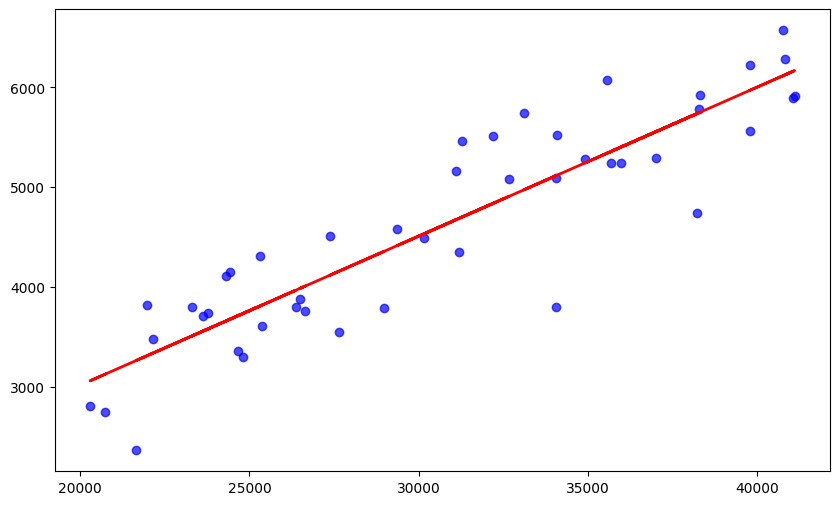

In [6]:
# Plotting the scatter plot
plt.figure(figsize=(10,6))
plt.scatter(df["Guest nights ('000)"], df["Tax revenue ($m)"], color='blue', alpha=0.7)

# Calculate trend line
x = df["Guest nights ('000)"]
y = df["Tax revenue ($m)"]
z = np.polyfit(x, y, 1)  # 1 indicates linear fit
p = np.poly1d(z)

# Plot trend line
plt.plot(x, p(x), color='red', linewidth=2, label=f'Trend line: y={z[0]:.2f}x+{z[1]:.2f}')

In [7]:
correlation_coefficient = df["Guest nights ('000)"].corr(df["Tax revenue ($m)"])
print(f'Correlation Coefficient: {correlation_coefficient:.2f}')

Correlation Coefficient: 0.90


# Building Predictive Model

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

In [9]:
# Prepare variables
X = df[["Guest nights ('000)"]].values.reshape(-1, 1)  # Reshape for sklearn
y = df["Tax revenue ($m)"].values

In [10]:
# Fit linear regression model
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_predict = model.predict(X)
r_squared = r2_score(y, y_predict)
mse = mean_squared_error(y, y_predict)

In [12]:
X_statisticalModel = sm.add_constant(X)
model_statistical = sm.OLS(y, X_statisticalModel).fit()

In [13]:
# Return results:
print(f'R-squared: {r_squared:.4f}')
print(f'Root Mean Squared Error: {np.sqrt(mse):.4f}')
print(f'Coefficients:\nIntercept: {model.intercept_}\nSlope: {model.coef_[0]}')

R-squared: 0.8078
Root Mean Squared Error: 462.3101
Coefficients:
Intercept: 33.55451458952302
Slope: 0.14920852652083844
